# Experiments

In this notebook we implement the experimental setting to reproduce the results in the paper. We begin with a study of the t-f localization of different spectrograms and conclude with a study on speech signals.

In [1]:
# Import libraries

from src.spectrogram import *
from src.barycenter import *
from src.cost_matrix import *
from src.display import *
from src.spectrogram import *
from src.experiment_metrics import *
from src.utils import *

import os
import matplotlib.pyplot as plt
import librosa
from scipy.signal.windows import hann
import numpy as np

from time import time
from tqdm import tqdm

## V. Synthetic signals

### V.A - Implementation details

In [25]:
# Common STFT parameters

W1, W2         = 100e-3, 20e-3
hop_size, nfft = 2e-3, 512
dur            = .5
sr             = 1000

## Compute supports and cost matrices for UOT (same-grid and different-grid settings)
# Compute spectrogram of random signal to retrieve time and frequency samplings
signal = np.random.randn(int(dur * sr))

# same-grid setting
X1 = Spectrogram(signal, sr, W1, hop_size_s=hop_size, nfft=nfft)
X2 = Spectrogram(signal, sr, W2, hop_size_s=hop_size, nfft=nfft)
f_bins, t_frames = X1.f_bins, X2.t_frames

c1_s, rows1_s, cols1_s = cost_matrix_horizontal_overlap(X1.f_bins, X2.t_frames, X2.t_frames, X1.window_size, X2.window_size, X1.hop_size, X2.hop_size)
c2_s, rows2_s, cols2_s = cost_matrix_vertical_overlap(X1.f_bins, X1.f_bins, X2.t_frames, X1.window_size, X2.window_size)

# different-grid setting
X1 = Spectrogram(signal, sr, W1, hop_size_s=W1 / 4, nfft=nfft) # 75% overlap
X2 = Spectrogram(signal, sr, W2, hop_size_s=hop_size, nfft=None) # complete frequency sampling

c1_d, rows1_d, cols1_d = cost_matrix_horizontal_overlap(X1.f_bins, X1.t_frames, X2.t_frames, X1.window_size, X2.window_size, X1.hop_size, X2.hop_size)
c2_d, rows2_d, cols2_d = cost_matrix_vertical_overlap(X1.f_bins, X2.f_bins, X2.t_frames, X1.window_size, X2.window_size)

# implementation parameters
eta = 10
tol = 1e-6
nItermax = 2000
N_sig = 100
f_min, f_max = 200, 400
min_dur, max_dur = W2/2, 2 * W2
min_onset, max_offset = 0.05, dur - 0.05 # sensure that tf packets don't touch temporal support limits

N_eval = 100 # number of variations of delta_f, for plotting

In [29]:
print("Different-grid setting, cost matrices finite entries:\n")
print(rf'C1 finite entries {c1_d.size}')
print(rf'C2 finite entries {c2_d.size}')

print("\nDifferent-grid setting, cost matrices finite entries:")
print(rf'C1 finite entries {c1_s.size}')
print(rf'C2 finite entries {c2_s.size}')

Different-grid setting, cost matrices finite entries:

C1 finite entries 308657
C2 finite entries 303450

Different-grid setting, cost matrices finite entries:
C1 finite entries 3758625
C2 finite entries 7096395


### V.B - Single tf packet

In [4]:
## Run experiment
np.random.seed(0)

# define error metrics for 5 spectrograms

f_error = np.zeros((5, N_sig, N_eval)) 
t_error = np.zeros((5, N_sig, N_eval))

# runtime for same-grid and different-grid barycenter computation
runtime    = np.zeros((2, N_sig))
iterations = np.zeros((2, N_sig))

signals = []
for i in tqdm(range(N_sig)):
    signal, f, t_on, t_off = single_tf_packet(sr, 
                                              dur, 
                                              f_min=f_min, 
                                              f_max=f_max, 
                                              min_dur=min_dur, 
                                              max_dur=max_dur, 
                                              min_onset=min_onset, 
                                              max_offset=max_offset)

    signals.append(signal)
    ## same-grid

    X1_s = Spectrogram(signal, sr, W1, hop_size_s=hop_size, nfft=nfft)
    X2_s = Spectrogram(signal, sr, W2, hop_size_s=hop_size, nfft=nfft)
    x1_s, x2_s = X1_s.spectrogram(), X2_s.spectrogram()
    x1_s = x1_s[:, :X2_s.t] # crop last frames to ensure same size

    # uot barycenter
    start = time()
    x_s, iter_s = uot_barycenter(x1_s.T.flatten(), 
                                 x2_s.T.flatten(), 
                                 c1_s, 
                                 c2_s, 
                                 rows1_s,
                                 cols1_s,
                                 rows2_s,
                                 cols2_s,
                                 eta=eta,
                                 bary_size=f_bins.size * t_frames.size,
                                 nItermax=nItermax,
                                 verbose=False,
                                 return_iter=True,
                                 thr=tol)
    runtime[0, i] = time() - start
    iterations[0, i] = iter_s
    x_s = x_s.reshape(t_frames.size, f_bins.size).T # reshape vector to spectrogram shape
    
    # geometric mean
    x_g = (x1_s * x2_s)**.5

    ## different-grid

    X1_d = Spectrogram(signal, sr, W1, hop_size_s=W1/4, nfft=nfft)
    X2_d = Spectrogram(signal, sr, W2, hop_size_s=hop_size)
    x1_d, x2_d = X1_d.spectrogram(), X2_d.spectrogram()
    
    # uot barycenter
    start = time()
    x_d, iter_d = uot_barycenter(x1_d.T.flatten(), 
                                 x2_d.T.flatten(), 
                                 c1_d, 
                                 c2_d, 
                                 rows1_d,
                                 cols1_d,
                                 rows2_d,
                                 cols2_d,
                                 eta=eta,
                                 bary_size=f_bins.size * t_frames.size,
                                 nItermax=nItermax,
                                 verbose=False,
                                 return_iter=True,
                                 thr=tol)
    runtime[1, i] = time() - start
    iterations[1, i] = iter_d

    x_d = x_d.reshape(t_frames.size, f_bins.size).T # reshape vector to spectrogram shape

    ## report metrics
    for j in range(N_eval):
        delta_f, delta_t = X1_s.f_bins[j], X2_s.t_frames[j]
        f_error[0, i, j] = error_frequency(x1_s, f, delta_f, f_bins)
        f_error[1, i, j] = error_frequency(x2_s, f, delta_f, f_bins)
        f_error[2, i, j] = error_frequency(x_g , f, delta_f, f_bins)
        f_error[3, i, j] = error_frequency(x_s , f, delta_f, f_bins)
        f_error[4, i, j] = error_frequency(x_d , f, delta_f, f_bins)
        t_error[0, i, j] = error_time(x1_s, t_on, t_off, delta_t, t_frames)
        t_error[1, i, j] = error_time(x2_s, t_on, t_off, delta_t, t_frames)
        t_error[2, i, j] = error_time(x_g , t_on, t_off, delta_t, t_frames)
        t_error[3, i, j] = error_time(x_s , t_on, t_off, delta_t, t_frames)
        t_error[4, i, j] = error_time(x_d , t_on, t_off, delta_t, t_frames)

# save error metrics
np.save("data/SINGLE_TF_error_time_x1", t_error[0])
np.save("data/SINGLE_TF_error_time_x2", t_error[1])
np.save("data/SINGLE_TF_error_time_xg", t_error[2])
np.save("data/SINGLE_TF_error_time_xs", t_error[3])
np.save("data/SINGLE_TF_error_time_xd", t_error[4])
np.save("data/SINGLE_TF_error_freq_x1", f_error[0])
np.save("data/SINGLE_TF_error_freq_x2", f_error[1])
np.save("data/SINGLE_TF_error_freq_xg", f_error[2])
np.save("data/SINGLE_TF_error_freq_xs", f_error[3])
np.save("data/SINGLE_TF_error_freq_xd", f_error[4])
np.save("data/SINGLE_TF_runtime_s", runtime[0])
np.save("data/SINGLE_TF_runtime_d", runtime[1])
np.save("data/SINGLE_TF_iterations_s", iterations[0])
np.save("data/SINGLE_TF_iterations_d", iterations[1])

100%|██████████| 100/100 [1:29:47<00:00, 53.87s/it]


Display tables I and II.

In [5]:
print("Error in time:\n")

print(f"{'Spectrogram':<22} {'E_t x 10^{-2}':>18}")
print(f"{'X1':<22} {f'{t_error[0, :, 0].mean() * 100:.3f} ± {t_error[0, :, 0].std() / np.sqrt(N_sig) * 100:.3f}':>18}")
print(f"{'X2':<22} {f'{t_error[1, :, 0].mean() * 100:.3f} ± {t_error[1, :, 0].std() / np.sqrt(N_sig) * 100:.3f}':>18}")
print(f"{'Geom':<22} {f'{t_error[2, :, 0].mean() * 100:.3f} ± {t_error[2, :, 0].std() / np.sqrt(N_sig) * 100:.3f}':>18}")
print(f"{'UOT (same grid)':<22} {f'{t_error[3, :, 0].mean() * 100:.3f} ± {t_error[3, :, 0].std() / np.sqrt(N_sig) * 100:.3f}':>18}")
print(f"{'UOT (different grid)':<22} {f'{t_error[4, :, 0].mean() * 100:.3f} ± {t_error[4, :, 0].std() / np.sqrt(N_sig) * 100:.3f}':>18}")

print("\nRuntime:\n")

print(f"{'UOT barycenter':<22} {'Runtime (s)':>16} {'Iterations':>16}")
print(f"{'UOT (same grid)':<22} {f'{runtime[0].mean():.3f} ± {runtime[0].std() / np.sqrt(N_sig):.3f}':>18} {f'{iterations[0].mean():.3f} ± {iterations[0].std() / np.sqrt(N_sig):.3f}':>18}")
print(f"{'UOT (different grid)':<22} {f'{runtime[1].mean():.3f} ± {runtime[1].std() / np.sqrt(N_sig):.3f}':>18} {f'{iterations[1].mean():.3f} ± {iterations[1].std() / np.sqrt(N_sig):.3f}':>18}")

Error in time:

Spectrogram                 E_t x 10^{-2}
X1                         39.029 ± 1.367
X2                          2.011 ± 0.246
Geom                        4.999 ± 0.460
UOT (same grid)             2.020 ± 0.246
UOT (different grid)        2.258 ± 0.266

Runtime:

UOT barycenter              Runtime (s)       Iterations
UOT (same grid)            53.401 ± 1.029    469.110 ± 8.562
UOT (different grid)        0.431 ± 0.005     57.410 ± 0.542


Display Fig. 5

Text(0.5, 0, '$\\Delta_f$ (Hz)')

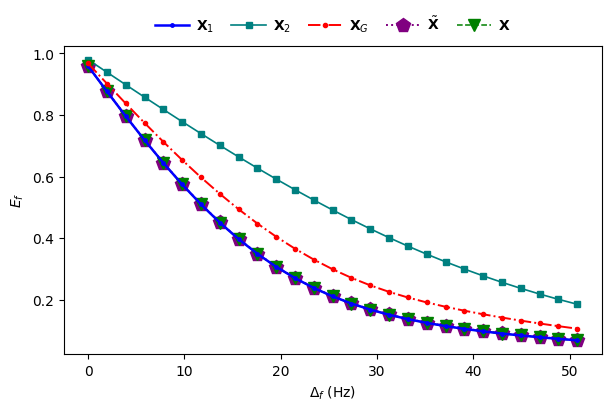

In [6]:
max_delta_f = 50
max_idx = idx_at_value(max_delta_f, f_bins)
x_axis = f_bins[:max_idx + 1]
axes = new_axes()

axes.plot(x_axis, f_error[0].mean(axis=0)[:max_idx + 1],  ls='-',  marker='.', c='blue',   lw=1.8, ms=5, zorder=5, label=r'$\mathbf{X}_1$',)
axes.plot(x_axis, f_error[1].mean(axis=0)[:max_idx + 1],  ls='-',  marker='s', c='teal',   lw=1.2, ms=4, zorder=3, label=r'$\mathbf{X}_2$',)
axes.plot(x_axis, f_error[2].mean(axis=0)[:max_idx + 1],  ls='-.', marker='o', c='red',    lw=1.4, ms=3, zorder=6, label=r"$\mathbf{X}_G$", )
axes.plot(x_axis, f_error[3].mean(axis=0)[:max_idx + 1],  ls=':',  marker='p', c='purple', lw=1.4, ms=10, zorder=2, label=r'$\tilde{\mathbf{X}}$')
axes.plot(x_axis, f_error[4].mean(axis=0)[:max_idx + 1],  ls='--', marker='v', c='green',  lw=1.1, ms=8, zorder=4, label=r"$\mathbf{X}$",)


axes.legend(
    loc='lower center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=5,
    frameon=False,
    handlelength=2.5,
    columnspacing=1.2,
    handletextpad=0.5,
    borderaxespad=0.0
)

axes.set_ylabel(r'$E_f$')
axes.set_xlabel(r'$\Delta_f$ (Hz)')

### V.C - Mixture of tf packets

In [8]:
## Run experiment
np.random.seed(0)

# define error metrics for 5 spectrograms
overall_error = np.zeros((5, N_sig, N_eval))

# runtime for same-grid and different-grid barycenter computation
runtime    = np.zeros((2, N_sig))
iterations = np.zeros((2, N_sig))

for i in tqdm(range(N_sig)):
    n_packets = np.random.randint(2, 11)
    signal, freqs, t_ons, t_offs = multi_tf_packet(sr, 
                                                   dur, 
                                                   n_packets,
                                                   f_min=f_min, 
                                                   f_max=f_max, 
                                                   min_dur=min_dur, 
                                                   max_dur=max_dur, 
                                                   min_onset=min_onset, 
                                                   max_offset=max_offset)

    ## same-grid

    X1_s = Spectrogram(signal, sr, W1, hop_size_s=hop_size, nfft=nfft)
    X2_s = Spectrogram(signal, sr, W2, hop_size_s=hop_size, nfft=nfft)
    x1_s, x2_s = X1_s.spectrogram(), X2_s.spectrogram()
    x1_s = x1_s[:, :X2_s.t] # crop last frames to ensure same size

    # uot barycenter
    start = time()
    x_s, iter_s = uot_barycenter(x1_s.T.flatten(), 
                                 x2_s.T.flatten(), 
                                 c1_s, 
                                 c2_s, 
                                 rows1_s,
                                 cols1_s,
                                 rows2_s,
                                 cols2_s,
                                 eta=eta,
                                 bary_size=f_bins.size * t_frames.size,
                                 nItermax=nItermax,
                                 verbose=False,
                                 return_iter=True,
                                 thr=tol)
    runtime[0, i] = time() - start
    iterations[0, i] = iter_s
    x_s = x_s.reshape(t_frames.size, f_bins.size).T # reshape vector to spectrogram shape
    
    # geometric mean
    x_g = (x1_s * x2_s)**.5

    ## different-grid

    X1_d = Spectrogram(signal, sr, W1, hop_size_s=W1/4, nfft=nfft)
    X2_d = Spectrogram(signal, sr, W2, hop_size_s=hop_size)
    x1_d, x2_d = X1_d.spectrogram(), X2_d.spectrogram()
    
    # uot barycenter
    start = time()
    x_d, iter_d = uot_barycenter(x1_d.T.flatten(), 
                                 x2_d.T.flatten(), 
                                 c1_d, 
                                 c2_d, 
                                 rows1_d,
                                 cols1_d,
                                 rows2_d,
                                 cols2_d,
                                 eta=eta,
                                 bary_size=f_bins.size * t_frames.size,
                                 nItermax=nItermax,
                                 verbose=False,
                                 return_iter=True,
                                 thr=tol)
    runtime[1, i] = time() - start
    iterations[1, i] = iter_d

    x_d = x_d.reshape(t_frames.size, f_bins.size).T # reshape vector to spectrogram shape

    ## report metrics

    for k in range(N_eval):
        delta_f = X1_s.f_bins[k]
        overall_error[0, i, k] = error_overall(x1_s, freqs, t_ons, t_offs, delta_f, 0, f_bins, t_frames) 
        overall_error[1, i, k] = error_overall(x2_s, freqs, t_ons, t_offs, delta_f, 0, f_bins, t_frames) 
        overall_error[2, i, k] = error_overall(x_g , freqs, t_ons, t_offs, delta_f, 0, f_bins, t_frames) 
        overall_error[3, i, k] = error_overall(x_s , freqs, t_ons, t_offs, delta_f, 0, f_bins, t_frames) 
        overall_error[4, i, k] = error_overall(x_d , freqs, t_ons, t_offs, delta_f, 0, f_bins, t_frames) 

# save error metrics
np.save("data/MULTI_TF_error_overall_x1", overall_error[0])
np.save("data/MULTI_TF_error_overall_x2", overall_error[1])
np.save("data/MULTI_TF_error_overall_xg", overall_error[2])
np.save("data/MULTI_TF_error_overall_xs", overall_error[3])
np.save("data/MULTI_TF_error_overall_xd", overall_error[4])
np.save("data/MULTI_TF_runtime_s", runtime[0])
np.save("data/MULTI_TF_runtime_d", runtime[1])
np.save("data/MULTI_TF_iterations_s", iterations[0])
np.save("data/MULTI_TF_iterations_d", iterations[1])

100%|██████████| 100/100 [3:25:23<00:00, 123.24s/it] 


Runtimes for table II.

In [9]:
print("\nRuntime:\n")

print(f"{'UOT barycenter':<22} {'Runtime (s)':>16} {'Iterations':>16}")
print(f"{'UOT (same grid)':<22} {f'{runtime[0].mean():.3f} ± {runtime[0].std() / np.sqrt(N_sig):.3f}':>18} {f'{iterations[0].mean():.3f} ± {iterations[0].std() / np.sqrt(N_sig):.3f}':>18}")
print(f"{'UOT (different grid)':<22} {f'{runtime[1].mean():.3f} ± {runtime[1].std() / np.sqrt(N_sig):.3f}':>18} {f'{iterations[1].mean():.3f} ± {iterations[1].std() / np.sqrt(N_sig):.3f}':>18}")


Runtime:

UOT barycenter              Runtime (s)       Iterations
UOT (same grid)           119.339 ± 0.961    944.860 ± 4.991
UOT (different grid)        3.780 ± 0.084    472.310 ± 9.846


Display Fig. 6

Text(0.5, 0, '$\\Delta_f$ (Hz)')

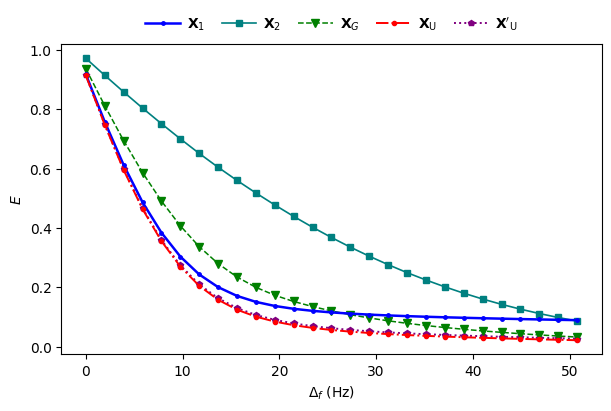

In [10]:
max_delta_f = 50
max_idx = idx_at_value(max_delta_f, f_bins)
x_axis = f_bins[:max_idx + 1]
axes = new_axes()

axes.plot(x_axis, overall_error[0, :].mean(axis=0)[:max_idx + 1],  ls='-',  marker='.', c='blue',   lw=1.8, ms=5, zorder=5, label=r'$\mathbf{X}_1$',)
axes.plot(x_axis, overall_error[1, :].mean(axis=0)[:max_idx + 1],  ls='-',  marker='s', c='teal',   lw=1.2, ms=4, zorder=3, label=r'$\mathbf{X}_2$',)
axes.plot(x_axis, overall_error[2, :].mean(axis=0)[:max_idx + 1],  ls='--', marker='v', c='green',  lw=1.1, ms=6, zorder=4, label=r'$\mathbf{X}_G$',)
axes.plot(x_axis, overall_error[3, :].mean(axis=0)[:max_idx + 1],  ls='-.', marker='o', c='red',    lw=1.4, ms=3, zorder=6, label=r"$\mathbf{X}_\mathrm{U}$", )
axes.plot(x_axis, overall_error[4, :].mean(axis=0)[:max_idx + 1],  ls=':',  marker='p', c='purple', lw=1.4, ms=4, zorder=2, label=r"$\mathbf{X}'_\mathrm{U}$", )


axes.legend(
    loc='lower center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=5,
    frameon=False,
    handlelength=2.5,
    columnspacing=1.2,
    handletextpad=0.5,
    borderaxespad=0.0
)

axes.set_ylabel(r'$E$')
axes.set_xlabel(r'$\Delta_f$ (Hz)')

## VI. Speech signals

Load dataset

In [49]:
sr = 8000
signals   = []
pitches   = []
p_samples = []

source_folder = 'example_sounds/PTDB-TUG/'

max_duration = 0

signal_to_display = 'M04_si1066'

idx_for_image = 0
for i, folder in enumerate(os.listdir(source_folder)):
    if folder == signal_to_display:
        idx_for_image = i # index of signal used for Fig. 8

    signal, _ = librosa.load(source_folder + folder + '/signal.wav', sr=sr)
    
    # load pitches, see PTDB-TUG reference
    A = np.load(source_folder + folder + "/pitch.npy")
    dt = np.dtype('float,float')
    A = np.array(A, dtype=dt)

    signals.append(signal)
    pitch_samples = A['f0']
    pitch         = A['f1']
    pitches.append(pitch)
    p_samples.append(pitch_samples)
    if signal.size > max_duration:
        max_duration = signal.size

# pad signals to same duration
for i in range(len(signals)):
    pad_length = max_duration - signals[i].size
    signals[i] = np.pad(signals[i], (0, pad_length))
    

### VI.A Implementation details

In [12]:
# Common STFT parameters
W1, W2         = 100e-3, 20e-3
hop_size, nfft = 5e-3, 1024

## Compute supports and cost matrices for UOT (same-grid and different-grid settings)

# Compute spectrogram of first signal to retrieve time and frequency samplings
signal = signals[0]

# same-grid setting
X1 = Spectrogram(signal, sr, W1, hop_size_s=hop_size, nfft=nfft)
X2 = Spectrogram(signal, sr, W2, hop_size_s=hop_size, nfft=nfft)
f_bins, t_frames = X1.f_bins, X2.t_frames

c1_s, rows1_s, cols1_s = cost_matrix_horizontal_overlap(X1.f_bins, X2.t_frames, X2.t_frames, X1.window_size, X2.window_size, X1.hop_size, X2.hop_size)
c2_s, rows2_s, cols2_s = cost_matrix_vertical_overlap(X1.f_bins, X1.f_bins, X2.t_frames, X1.window_size, X2.window_size)

# different-grid setting
X1 = Spectrogram(signal, sr, W1, hop_size_s=W1 / 4, nfft=nfft) # 75% overlap
X2 = Spectrogram(signal, sr, W2, hop_size_s=hop_size, nfft=None) # complete frequency sampling

c1_d, rows1_d, cols1_d = cost_matrix_horizontal_overlap(X1.f_bins, X1.t_frames, X2.t_frames, X1.window_size, X2.window_size, X1.hop_size, X2.hop_size)
c2_d, rows2_d, cols2_d = cost_matrix_vertical_overlap(X1.f_bins, X2.f_bins, X2.t_frames, X1.window_size, X2.window_size)

# implementation parameters
N_sig = len(signals)
eta = 1
tol = 5e-7
nItermax = 2000

N_eval = 50 # number of variations of delta_f, for plotting

### VI.B - Harmonic localization

In [ ]:
## Run experiment
np.random.seed(0)

# define error metrics for 5 spectrograms
harmonic_error = np.zeros((5, N_sig, N_eval))

# runtime for same-grid and different-grid barycenter computation
runtime    = np.zeros((2, N_sig))
iterations = np.zeros((2, N_sig))

for i in tqdm(range(N_sig)):
    signal = signals[i]

    ## same-grid
    X1_s = Spectrogram(signal, sr, W1, hop_size_s=hop_size, nfft=nfft)
    X2_s = Spectrogram(signal, sr, W2, hop_size_s=hop_size, nfft=nfft)
    x1_s, x2_s = X1_s.spectrogram(), X2_s.spectrogram()
    x1_s = x1_s[:, :X2_s.t] # crop last frames to ensure same size

    # uot barycenter
    start = time()
    x_s, iter_s = uot_barycenter(x1_s.T.flatten(), 
                                 x2_s.T.flatten(), 
                                 c1_s, 
                                 c2_s, 
                                 rows1_s,
                                 cols1_s,
                                 rows2_s,
                                 cols2_s,
                                 eta=eta,
                                 bary_size=f_bins.size * t_frames.size,
                                 nItermax=nItermax,
                                 verbose=False,
                                 return_iter=True,
                                 thr=tol)
    runtime[0, i] = time() - start
    iterations[0, i] = iter_s
    x_s = x_s.reshape(t_frames.size, f_bins.size).T # reshape vector to spectrogram shape

    # geometric mean
    x_g = (x1_s * x2_s)**.5

    ## different-grid

    X1_d = Spectrogram(signal, sr, W1, hop_size_s=W1/4, nfft=nfft)
    X2_d = Spectrogram(signal, sr, W2, hop_size_s=hop_size)
    x1_d, x2_d = X1_d.spectrogram(), X2_d.spectrogram()
    
    # uot barycenter
    start = time()
    x_d, iter_d = np.zeros_like(x1_s), 0
    x_d, iter_d = uot_barycenter(x1_d.T.flatten(), 
                                 x2_d.T.flatten(), 
                                 c1_d, 
                                 c2_d, 
                                 rows1_d,
                                 cols1_d,
                                 rows2_d,
                                 cols2_d,
                                 eta=eta,
                                 bary_size=f_bins.size * t_frames.size,
                                 nItermax=nItermax,
                                 verbose=False,
                                 return_iter=True,
                                 thr=tol)
    runtime[1, i] = time() - start
    iterations[1, i] = iter_d

    x_d = x_d.reshape(t_frames.size, f_bins.size).T # reshape vector to spectrogram shape

    if i == idx_for_image:
        x1_image = x1_s
        x2_image = x2_s
        xd_image = x_d

    # report metrics
    for j in range(N_eval):
        delta_f = X1_s.f_bins[j]
        harmonic_error[0, i, j] = error_harmonic(x1_s, pitches[i], p_samples[i], delta_f, f_bins, t_frames, sr/2)
        harmonic_error[1, i, j] = error_harmonic(x2_s, pitches[i], p_samples[i], delta_f, f_bins, t_frames, sr/2)
        harmonic_error[2, i, j] = error_harmonic(x_g , pitches[i], p_samples[i], delta_f, f_bins, t_frames, sr/2)
        harmonic_error[3, i, j] = error_harmonic(x_s , pitches[i], p_samples[i], delta_f, f_bins, t_frames, sr/2)
        harmonic_error[4, i, j] = error_harmonic(x_d , pitches[i], p_samples[i], delta_f, f_bins, t_frames, sr/2)

# save error metrics
np.save("data/SPEECH_error_harmonic_x1", harmonic_error[0])
np.save("data/SPEECH_error_harmonic_x2", harmonic_error[1])
np.save("data/SPEECH_error_harmonic_xg", harmonic_error[2])
np.save("data/SPEECH_error_harmonic_xs", harmonic_error[3])
np.save("data/SPEECH_error_harmonic_xd", harmonic_error[4])
np.save("data/SPEECH_runtime_s", runtime[0])
np.save("data/SPEECH_runtime_d", runtime[1])
np.save("data/SPEECH_iterations_s", iterations[0])
np.save("data/SPEECH_iterations_d", iterations[1])

100%|██████████| 100/100 [4:26:45<00:00, 160.05s/it] 


Fig. 7

Text(0.5, 0, '$\\Delta_f$ (Hz)')

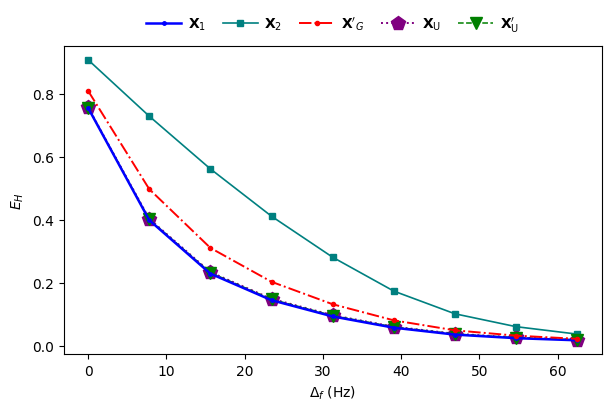

In [16]:
max_delta_f = 60
max_idx = idx_at_value(max_delta_f, f_bins)
x_axis = f_bins[:max_idx + 1]
axes = new_axes()

axes.plot(x_axis, harmonic_error[0].mean(axis=0)[:max_idx + 1],  ls='-',  marker='.', c='blue',   lw=1.8, ms=5, zorder=5, label=r'$\mathbf{X}_1$',)
axes.plot(x_axis, harmonic_error[1].mean(axis=0)[:max_idx + 1],  ls='-',  marker='s', c='teal',   lw=1.2, ms=4, zorder=3, label=r'$\mathbf{X}_2$',)
axes.plot(x_axis, harmonic_error[2].mean(axis=0)[:max_idx + 1],  ls='-.', marker='o', c='red',    lw=1.4, ms=3, zorder=6, label=r"$\mathbf{X}'_G$", )
axes.plot(x_axis, harmonic_error[3].mean(axis=0)[:max_idx + 1],  ls=':',  marker='p', c='purple', lw=1.4, ms=10, zorder=2, label=r'$\mathbf{X}_\mathrm{U}$',)
axes.plot(x_axis, harmonic_error[4].mean(axis=0)[:max_idx + 1],  ls='--', marker='v', c='green',  lw=1.1, ms=8, zorder=4, label=r"$\mathbf{X}_\mathrm{U}'$",)


axes.legend(
    loc='lower center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=5,
    frameon=False,
    handlelength=2.5,
    columnspacing=1.2,
    handletextpad=0.5,
    borderaxespad=0.0
)

axes.set_ylabel(r'$E_H$')
axes.set_xlabel(r'$\Delta_f$ (Hz)')

Table III

In [17]:
print("\nRuntime:\n")

print(f"{'UOT barycenter':<22} {'Runtime (s)':>16} {'Iterations':>16}")
print(f"{'UOT (same grid)':<22} {f'{runtime[0].mean():.3f} ± {runtime[0].std() / np.sqrt(N_sig):.3f}':>18} {f'{iterations[0].mean():.3f} ± {iterations[0].std() / np.sqrt(N_sig):.3f}':>18}")
print(f"{'UOT (different grid)':<22} {f'{runtime[1].mean():.3f} ± {runtime[1].std() / np.sqrt(N_sig):.3f}':>18} {f'{iterations[1].mean():.3f} ± {iterations[1].std() / np.sqrt(N_sig):.3f}':>18}")


Runtime:

UOT barycenter              Runtime (s)       Iterations
UOT (same grid)           148.938 ± 4.117    341.440 ± 9.406
UOT (different grid)        9.356 ± 0.214    104.800 ± 2.397


Fig. 8

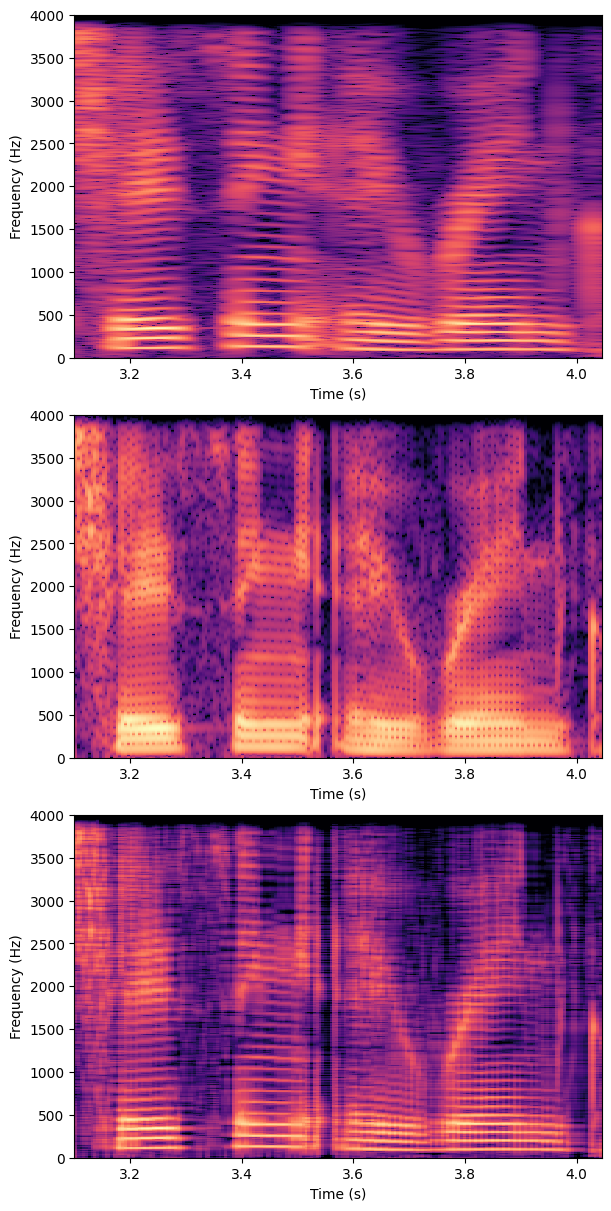

In [18]:
low_t, high_t = 3.1, 4.05
axes = new_axes(3)
display_spectrogram(x1_image, ax=axes[0], f_bins=f_bins, t_frames=t_frames, log=True, low_t=low_t, high_t=high_t)
display_spectrogram(x2_image, ax=axes[1], f_bins=f_bins, t_frames=t_frames, log=True, low_t=low_t, high_t=high_t)
display_spectrogram(xd_image, ax=axes[2], f_bins=f_bins, t_frames=t_frames, log=True, low_t=low_t, high_t=high_t)